In [2]:
# import standard tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# stop pandas from hiding columns
pd.set_option('display.width', 120)

In [3]:
# load the train and test files member 1 saved in the data folder
# using ../ to go up one level from the notebooks folder
train_df = pd.read_csv('../data/train_clean.csv')
test_df = pd.read_csv('../data/test_clean.csv')

print("train set shape:", train_df.shape)
print("test set shape:", test_df.shape)

train set shape: (5455, 96)
test set shape: (1364, 96)


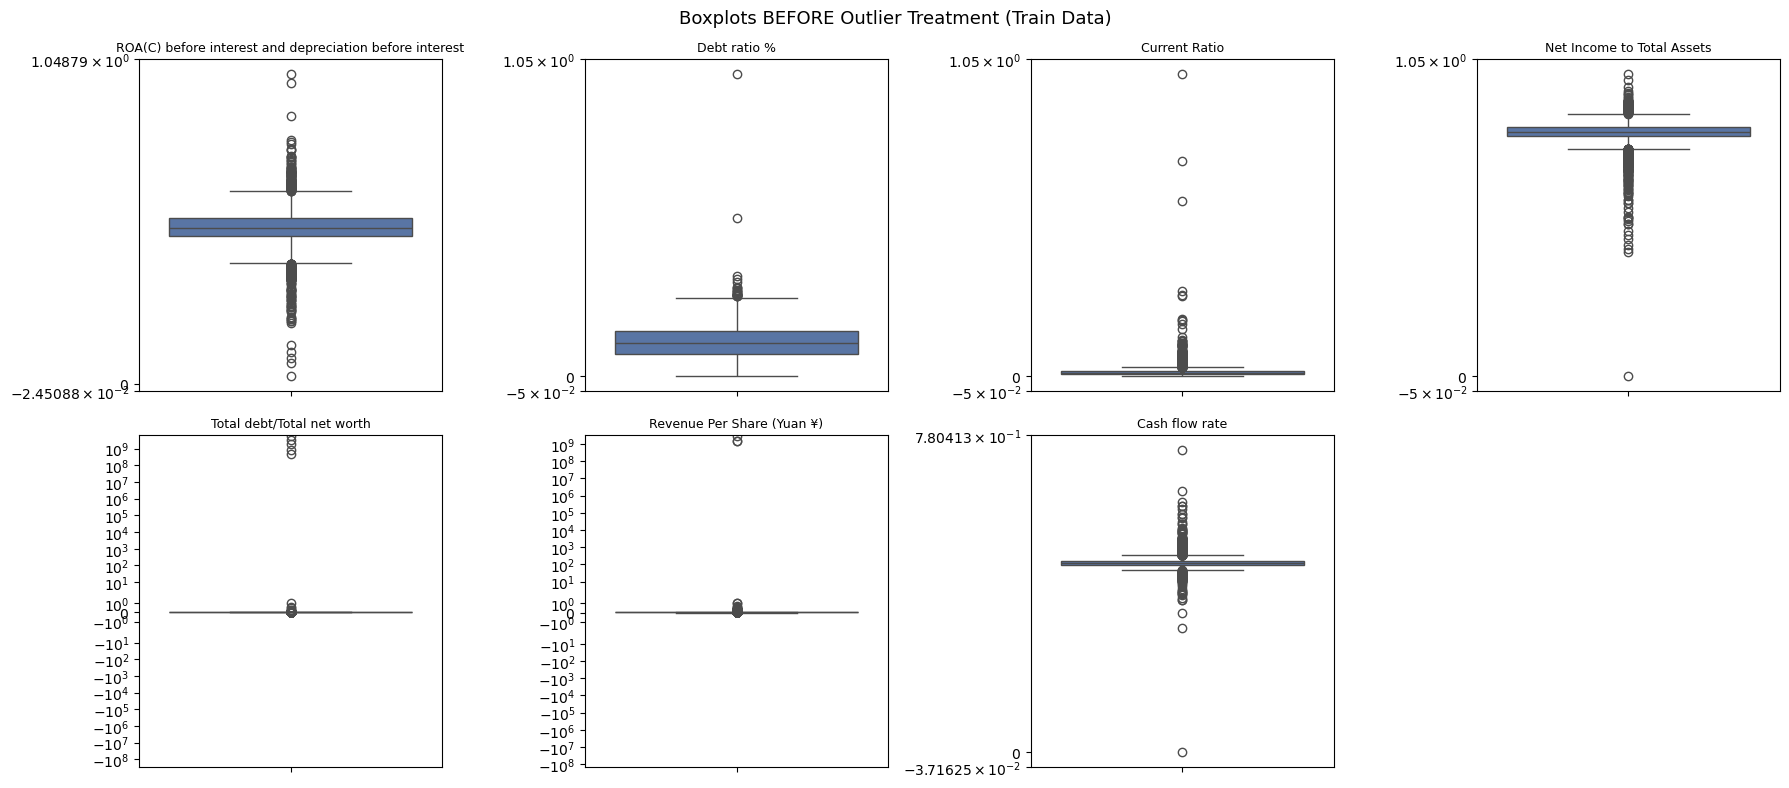

In [4]:
# these r the main financial ratios we want to check for outliers
key_cols = [
    'ROA(C) before interest and depreciation before interest',
    'Debt ratio %',
    'Current Ratio',
    'Net Income to Total Assets',
    'Total debt/Total net worth',
    'Revenue Per Share (Yuan ¥)',
    'Cash flow rate'
]

# plot boxplots before we fix anything
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, c in enumerate(key_cols):
    sns.boxplot(y=train_df[c], ax=axes[i], color='#4C72B0')
    axes[i].set_title(c, fontsize=9)
    # use symlog so extreme outliers dont squash the box flat
    axes[i].set_yscale('symlog')
    axes[i].set_ylabel('')

axes[-1].axis('off')
plt.suptitle('Boxplots BEFORE Outlier Treatment (Train Data)', fontsize=13)
plt.tight_layout()

# save to eda results folder
plt.savefig('../results/eda_visualizations/member2_boxplot_before.png', dpi=110)
plt.show()

In [5]:
# func to get iqr bounds
def get_outlier_bounds(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

# create copies so we dont mess up original dfs
train_treated = train_df.copy()
test_treated = test_df.copy()

capping_log = []

# loop through each key column
for c in key_cols:
    # calc bounds using ONLY train data to stop data leakage
    lower, upper = get_outlier_bounds(train_df[c])
    
    before_min, before_max = train_df[c].min(), train_df[c].max()
    
    # clip both train and test sets using the train bounds
    train_treated[c] = train_treated[c].clip(lower=lower, upper=upper)
    test_treated[c] = test_treated[c].clip(lower=lower, upper=upper)
    
    capping_log.append({
        'Feature': c,
        'Min before': before_min, 
        'Max before': before_max,
        'Min after': train_treated[c].min(), 
        'Max after': train_treated[c].max()
    })

# show what got changed
print("--- capping log (train data) ---")
print(pd.DataFrame(capping_log))

--- capping log (train data) ---
                                             Feature  Min before    Max before  Min after  Max after
0  ROA(C) before interest and depreciation before...    0.024277  1.000000e+00   0.388363   0.622361
1                                       Debt ratio %    0.000000  1.000000e+00   0.000000   0.263060
2                                      Current Ratio    0.000000  1.000000e+00   0.000000   0.029702
3                         Net Income to Total Assets    0.000000  1.000000e+00   0.752468   0.870264
4                         Total debt/Total net worth    0.000000  5.930000e+09   0.000000   0.018695
5                         Revenue Per Share (Yuan ¥)    0.000000  3.020000e+09   0.000000   0.091671
6                                     Cash flow rate    0.000000  7.432509e-01   0.447481   0.484974


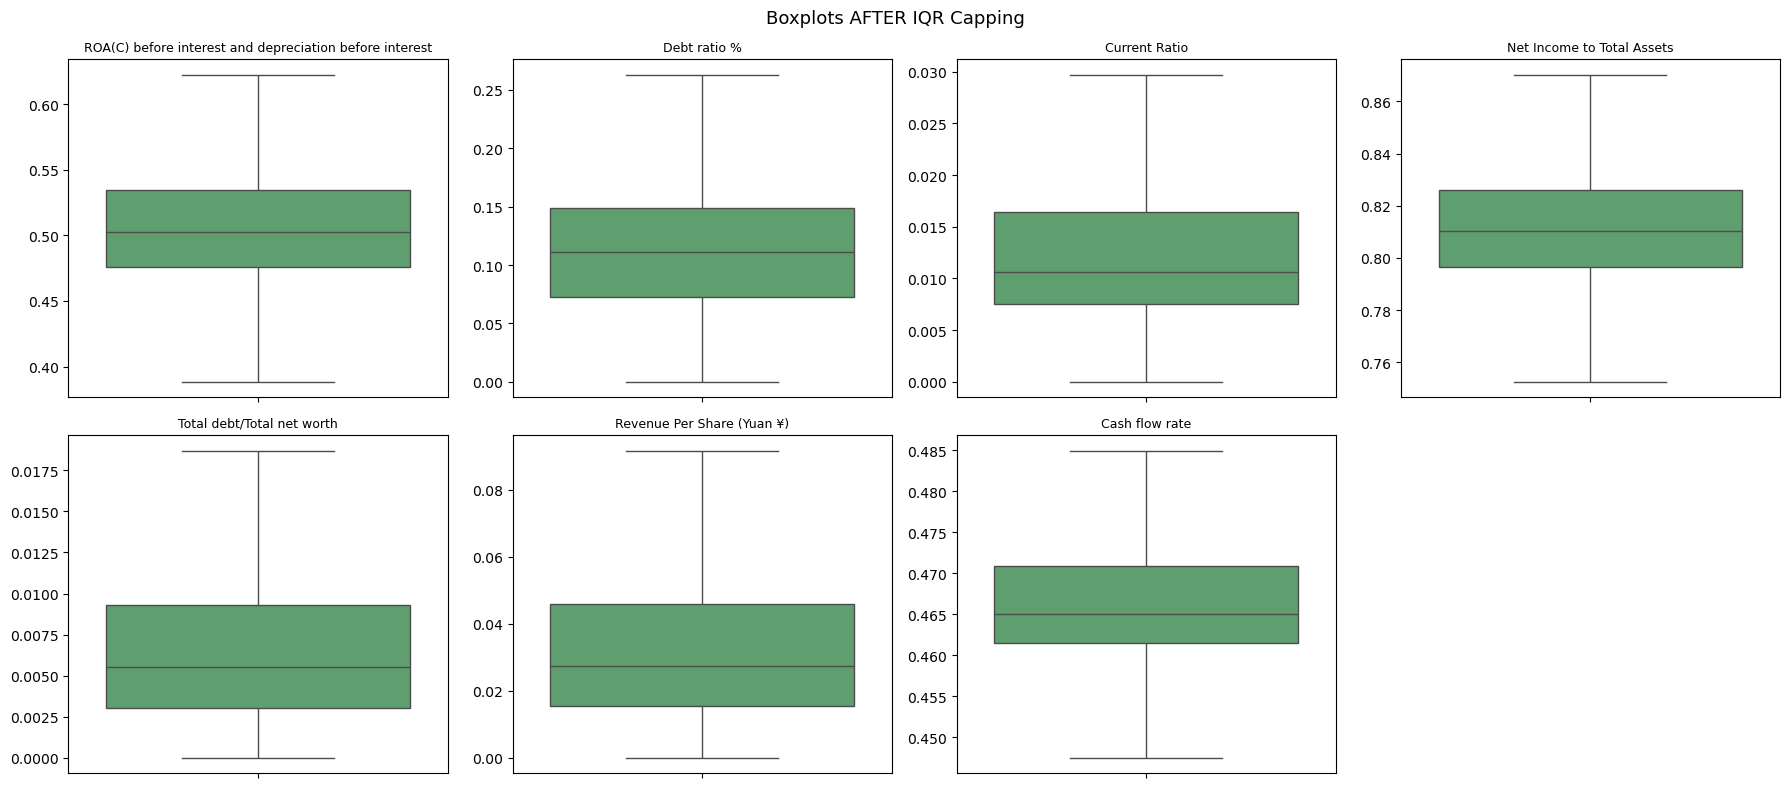

saved train_outliers.csv and test_outliers.csv


In [6]:
# plot boxplots again to show they r fixed
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, c in enumerate(key_cols):
    sns.boxplot(y=train_treated[c], ax=axes[i], color='#55A868')
    axes[i].set_title(c, fontsize=9)
    axes[i].set_ylabel('')

axes[-1].axis('off')
plt.suptitle('Boxplots AFTER IQR Capping', fontsize=13)
plt.tight_layout()

# save the second visual
plt.savefig('../results/eda_visualizations/member2_boxplot_after.png', dpi=110)
plt.show()

# save intermediate files to data folder for member 3
train_treated.to_csv('../data/train_outliers.csv', index=False)
test_treated.to_csv('../data/test_outliers.csv', index=False)

print("saved train_outliers.csv and test_outliers.csv")